# Modelación Computacional para SUT: Herramientas y Procesos

---

## Autor: Santiago Ayala

---

¡Bienvenid@ a mi notebook! 👻👻👻

Este *notebook* está diseñado para registrar y mostrar paso a paso a través de las metodologías, herramientas y flujos de trabajo fundamentales utilizados en la **modelación computacional** del proyecto SUT 2026. Registrare el ciclo completo: desde la preparación de los datos y la configuración del entorno, hasta la simulación y validación de los modelos.

**Objetivo principal:** Proporcionar una comprensión práctica de cómo integrar herramientas computacionales para resolver el analisis propuesto por el semillero SUT en el 2026.

**Nota**: Es importante descargar todas las herramientas usadas por OSMNX para la correcta ejecución del notebook.


## 📑 Tabla de Contenido

1. [Configuración del Entorno de Trabajo](#paso-1)
2. [Descarga y preparación de datos](#paso-2)
3. [Procesamiento de datos en QGIS](#paso-3)

<a id="paso-1"></a>
## 1. Configuración del Entorno de Trabajo e Importación de Librerías

Para este modelo, nos apoyaremos algunas librerías fundamentales enfocadas en el análisis espacial y la teoría de grafos. Estas herramientas nos permitirán estructurar la información geográfica y modelar infraestructuras urbanas, como redes peatonales o viales

In [9]:
import networkx as nx #Descarga y procesa la infraestructura real (calles, redes peatonales) directamente desde OpenStreetMap.

import osmnx as ox #Convierte esa infraestructura en grafos (nodos y aristas) para realizar cálculos de conectividad, distancias y rutas óptimas.

import geopandas as gpd #Maneja los atributos espaciales y geometrías (puntos, líneas, polígonos) en un formato de tablas, facilitando el cruce de datos geográficos.

ox.settings.log_console = True #Por último, habilitamos los mensajes en consola (log_console = True) para monitorear el progreso de las descargas de datos y verificamos la versión de OSMnx instalada.
ox.__version__

'2.1.1'

<a id="paso-2"></a>
## 2. Descarga y preparación de datos

Para extraer la geometría urbana con osmnx, tenemos tres alternativas principales para delimitar nuestra zona de estudio:

**1.** Por nombre del lugar (**graph_from_place**): Ingresamos el nombre oficial de la ciudad, comuna o barrio. La librería buscará sus límites político-administrativos exactos.

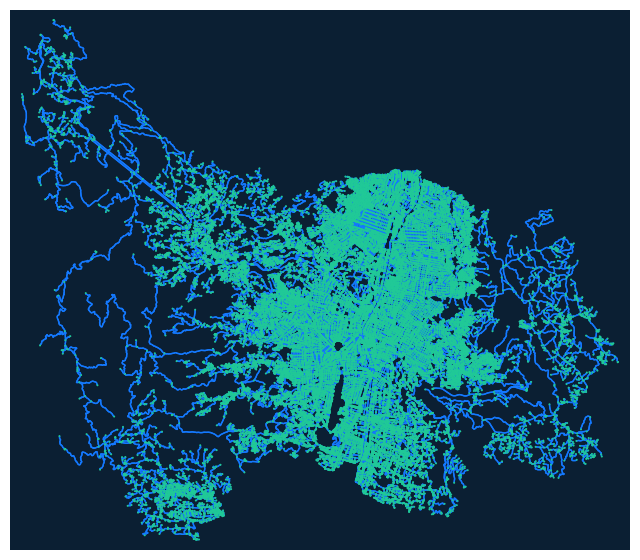

In [3]:
A = ox.graph.graph_from_place("Medellin, Antioquia, Colombia", network_type="walk")
fig, ax = ox.plot.plot_graph(
    A,
    bgcolor="#0B1F33",       # Color de fondo
    edge_color="#1479FF",    # Color de las líneas (calles/aristas)
    node_color="#20C997",    # Color de los puntos (intersecciones/nodos)
    node_size=2,            # Tamaño de los nodos (opcional)
    edge_linewidth=1         # Grosor de las líneas (opcional)
)

**2.** Por polígono (**graph_from_polygon**): Ideal si tenemos un área de estudio con una forma irregular y específica, previamente delimitada y exportada desde un software siendo QGIS en este caso.

Para este caso traemos el polígono del municipio de Medellín desde QGIS para después extraer su información.


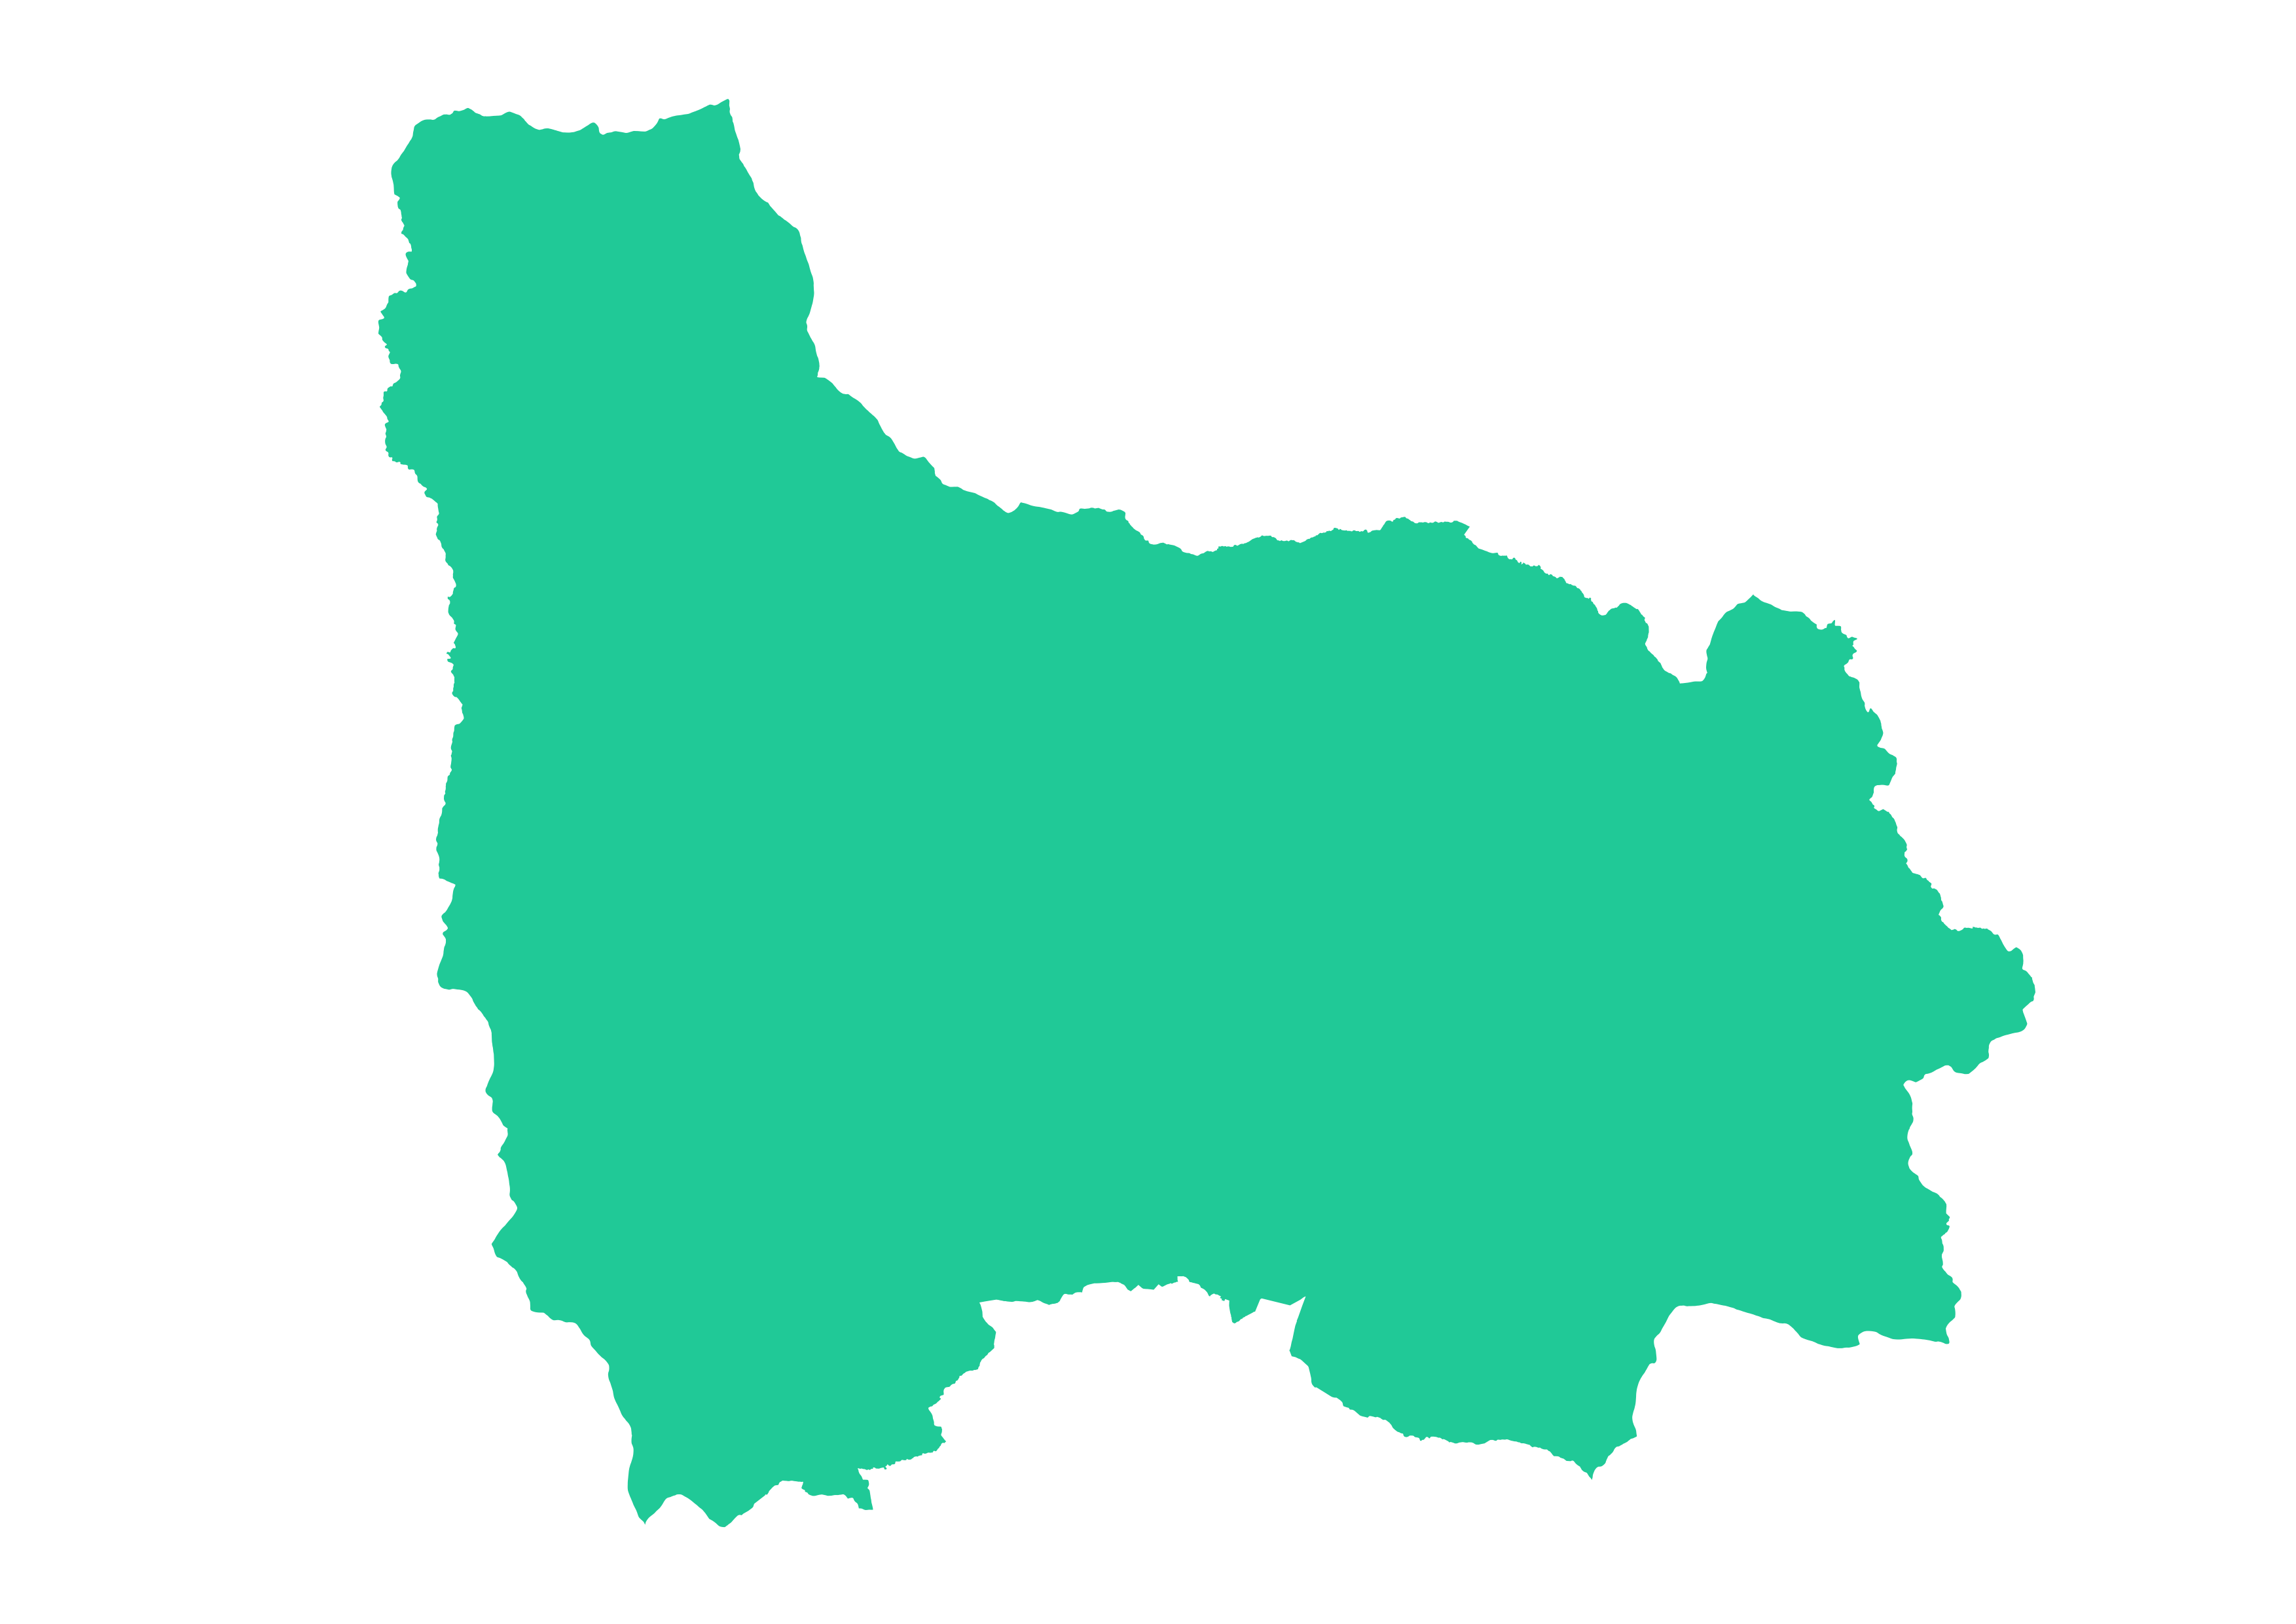

In [15]:
from IPython.display import Image, display

display(Image(filename="../Images/Medellin.png", width=500))

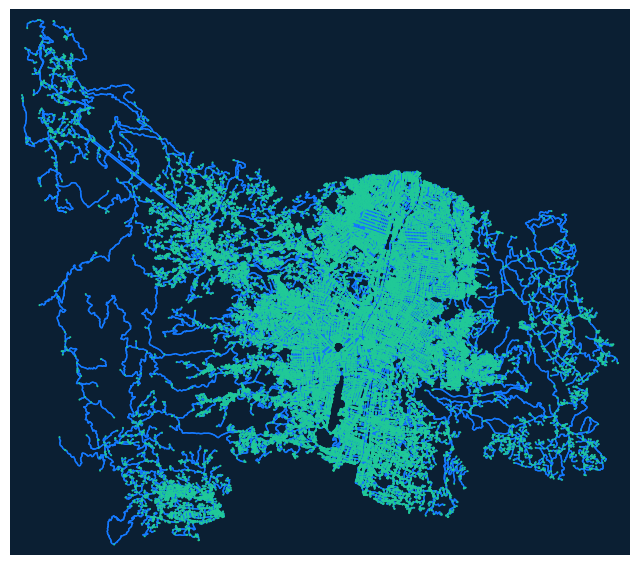

In [5]:
zona = gpd.read_file("../GPKG/Medellin.gpkg")
polygon = zona.geometry.iloc[0]
B = ox.graph.graph_from_polygon(
    polygon,
    network_type="walk"
)

fig, ax = ox.plot.plot_graph(
    B,
    bgcolor="#0B1F33",       # Color de fondo
    edge_color="#1479FF",    # Color de las líneas (calles/aristas)
    node_color="#20C997",    # Color de los puntos (intersecciones/nodos)
    node_size=2,            # Tamaño de los nodos (opcional)
    edge_linewidth=1         # Grosor de las líneas (opcional)
)

**3.** Por punto y radio (**graph_from_point**): Definimos una coordenada central (centroide) y establecemos un radio en metros. El modelo descargará todo lo que se encuentre dentro de esa área circular.

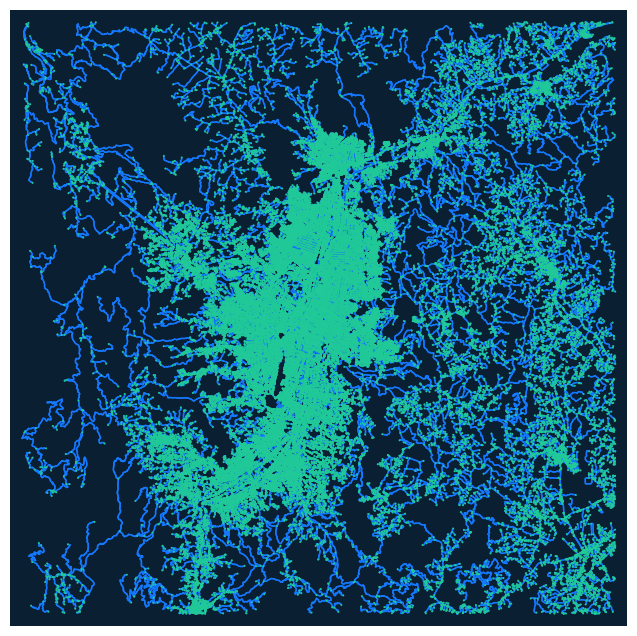

In [6]:
lat, lon = ox.geocoder.geocode(
    "<Plaza Botero, Medellín, Antioquia, Colombia" #Convertimos la dirección o nombre del lugar en coordenadas (Latitud, Longitud)
)
centroide = (lat, lon)  # latitud, longitud

C = ox.graph_from_point(
    centroide,
    dist=18000,              # Radio de 18000 m o 18 Km
    network_type="walk"
)

fig, ax = ox.plot.plot_graph(
    C,
    bgcolor="#0B1F33",       # Color de fondo
    edge_color="#1479FF",    # Color de las líneas (calles/aristas)
    node_color="#20C997",    # Color de los puntos (intersecciones/nodos)
    node_size=2,            # Tamaño de los nodos (opcional)
    edge_linewidth=1         # Grosor de las líneas (opcional)
)

<a id="paso-3"></a>
## 3. Procesamiento de datos en QGIS

Una vez descargada y estructurada la red urbana, el siguiente paso es exportar esta información para procesarla en un Sistema de Información Geográfica (SIG) como QGIS. Esto nos permitirá realizar cruces espaciales, clasificaciones visuales y análisis cartográficos más avanzados.

Para lograr esta exportación, primero debemos separar nuestro modelo de red en dos capas vectoriales tradicionales: puntos (intersecciones) y líneas (calles).

In [8]:

# 'nodes' almacenará la geometría de puntos y 'edges' la geometría de líneas con todos sus atributos.
nodes, edges = ox.graph_to_gdfs(C) #Usamos la C al ser la más completa en este caso.


# Guardamos los puntos en formato GeoPackage, el estándar más recomendado para QGIS.
nodes.to_file(
    "../GPKG/Walk_nodes_AMVA.gpkg", 
    layer="nodos", 
    driver="GPKG"
)

# Guardamos la red de líneas en su respectivo archivo Shapefile.
edges.to_file(
    "../GPKG/Walk_edges_AMVA.gpkg", 
    layer="ejes", 
    driver="GPKG"
)

Para la extracción de la red peatonal de La Aurora, se tomará como base su límite político-administrativo, aplicando un área de influencia (buffer) de 500 metros con el fin de capturar toda la red circundante que impacta directamente el sector.


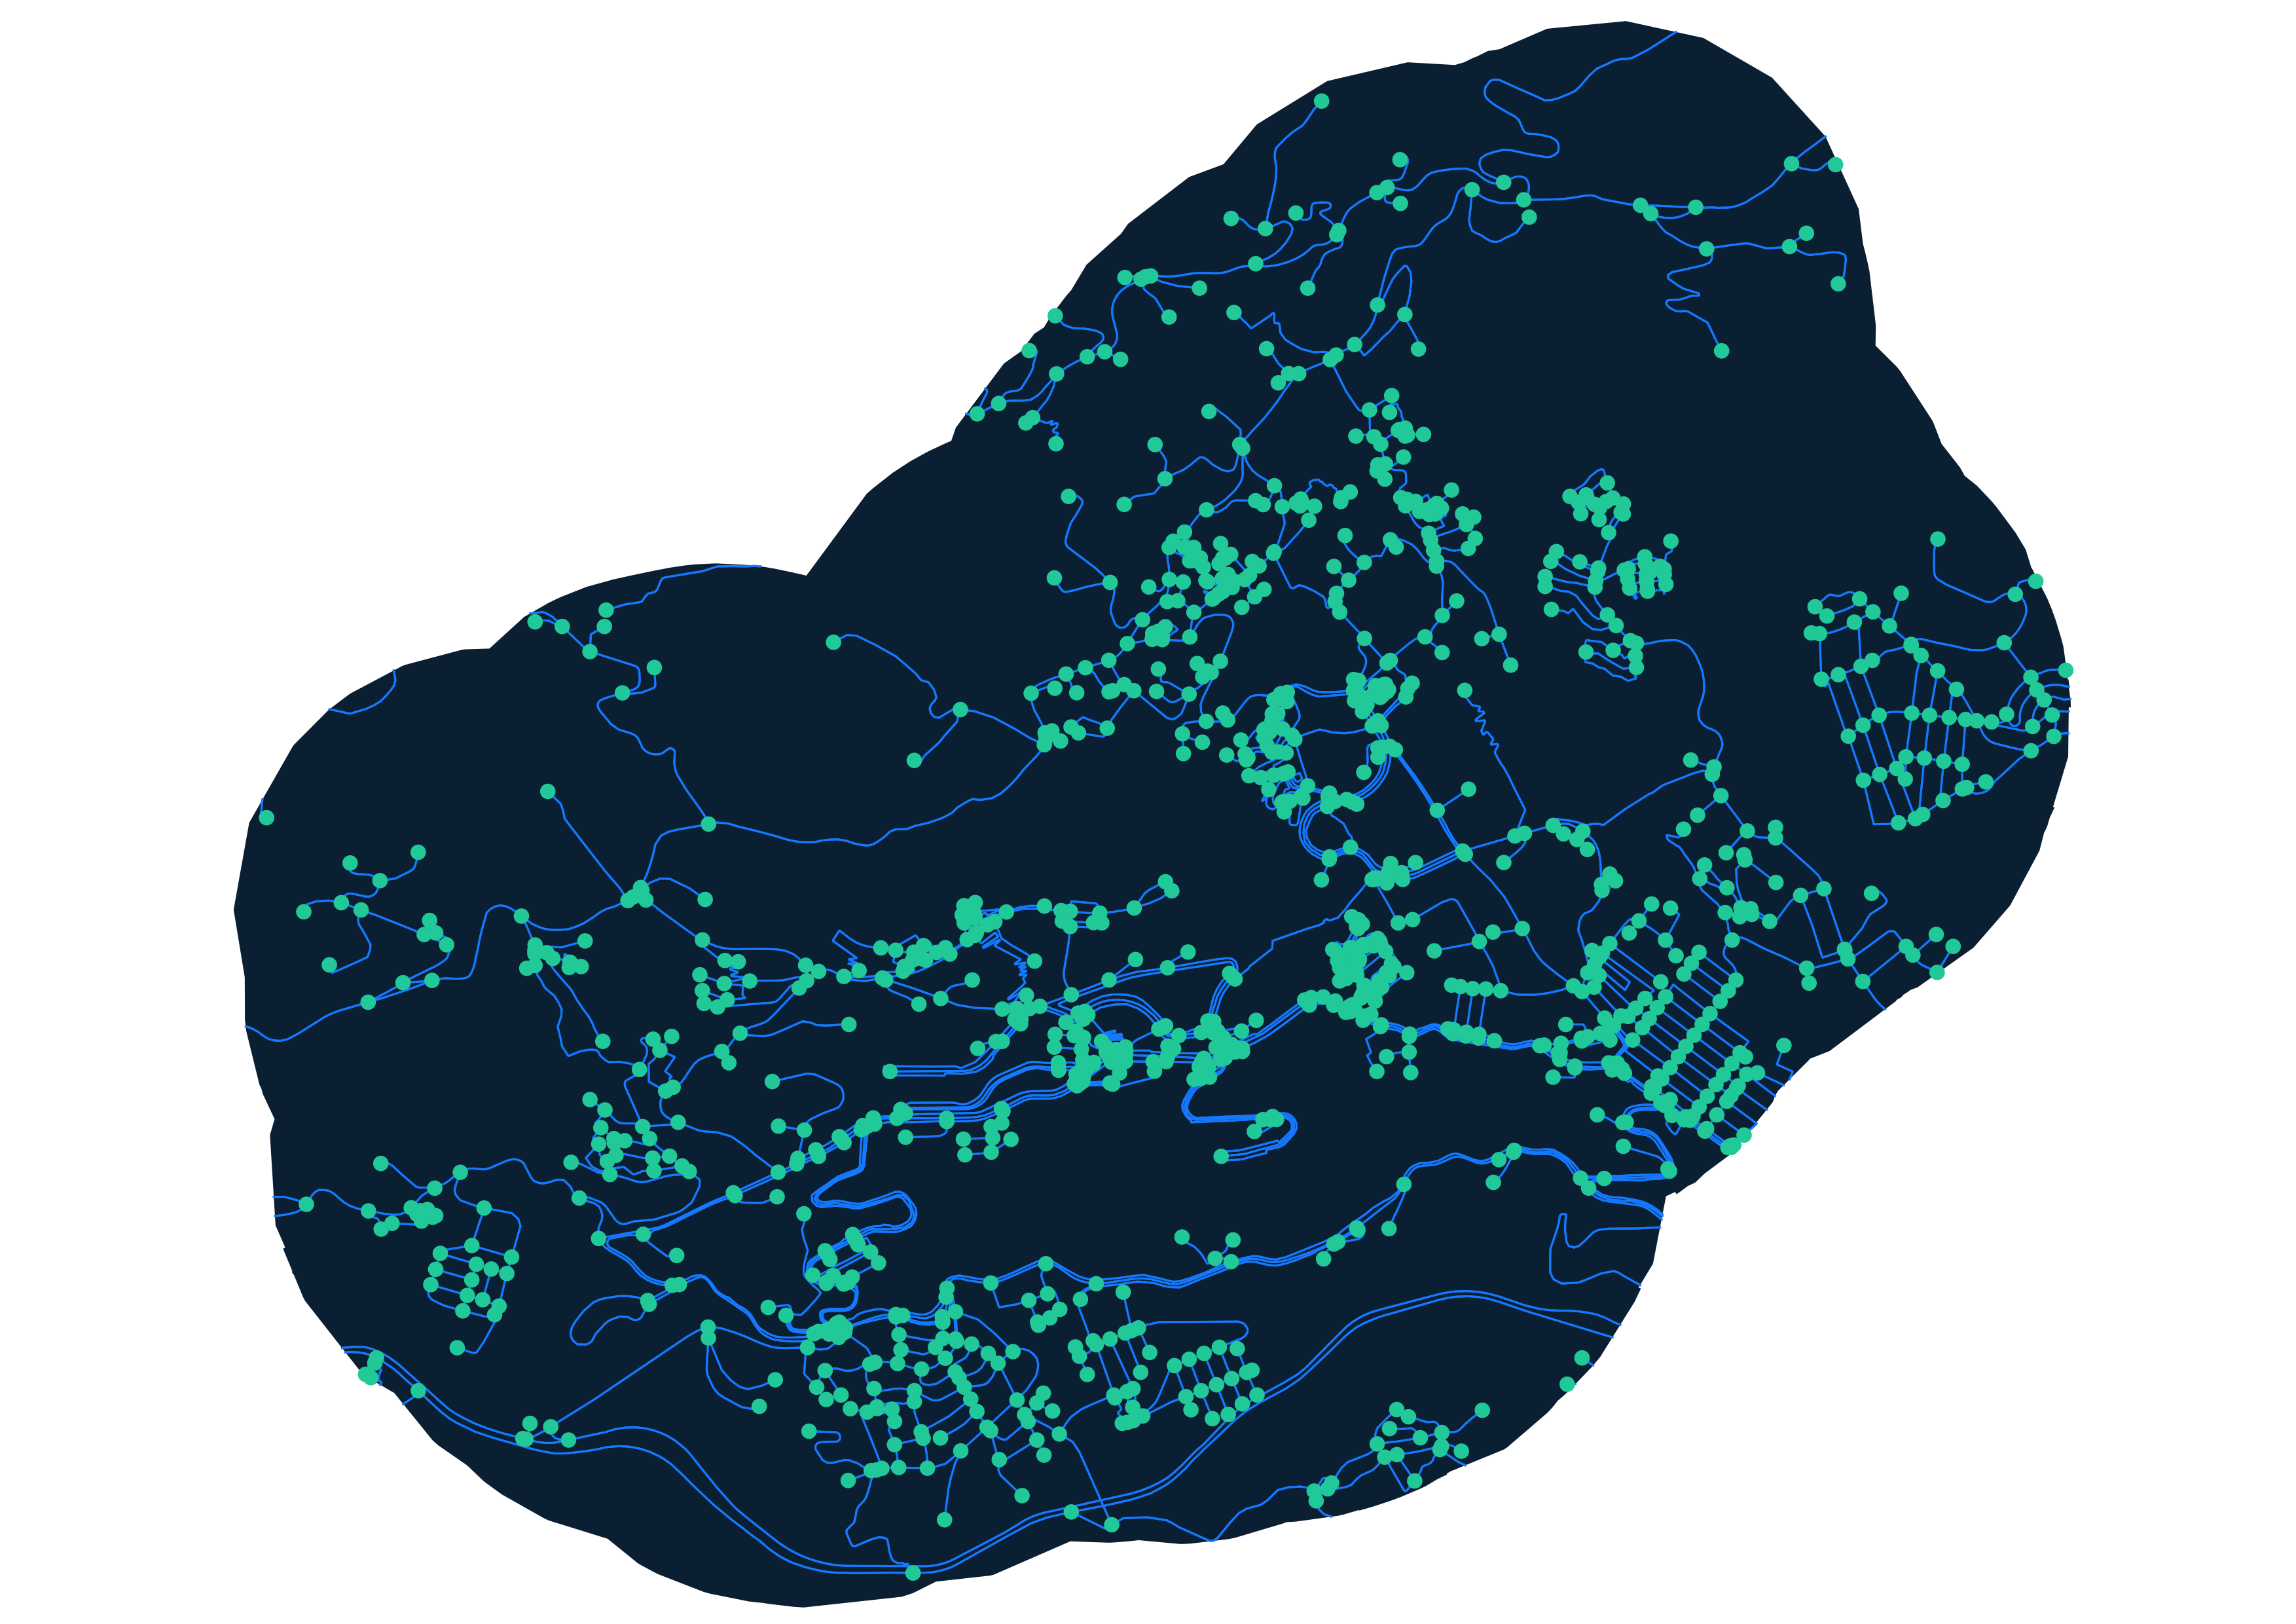

In [14]:
from IPython.display import Image, display

display(Image(filename="../Images/Red_Peatonal_Aurora.png", width=500))